In [9]:
import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

hbar = 1.054571817 * 1e-34
eV = 1.6 * 1e-19
ps = 1e-12

In [11]:
def plot_signals(signals, t_axis = None, labels=None, points=None, pointlabels=None):
    fig, ax = plt.subplots()
    for s, sig in enumerate(signals):
        if t_axis is None:
            t_axis = np.linspace(0.,1., num=len(sig), endpoint=True)
        ax.plot(t_axis, sig, label=labels[s])
    if points is not None:
        for p, pts in enumerate(points):
            ax.scatter(pts[0], pts[1], marker='x', label=pointlabels[p])
    if labels is not None or pointlabels is not None: ax.legend()
    plt.show()

def FixRho(rho):
    # Handle both 2D (N,N) and 3D batched (B,N,N) inputs
    squeeze = rho.ndim == 2
    if squeeze:
        rho = rho.unsqueeze(0)

    # 1. Force Hermitian (more aggressively)
    rho_dag = rho.conj().transpose(1, 2)
    rho = (rho + rho_dag) / 2
    # Add tiny regularization to diagonal to help convergence
    eps = 1e-10
    eye = torch.eye(rho.shape[-1], dtype=rho.dtype, device=rho.device)
    rho = rho + eps * eye.unsqueeze(0)

    # 2. Batched eigen-decomposition
    eigvals, eigvecs = torch.linalg.eigh(rho)

    # 3. Clip negative eigenvalues
    eigvals = torch.clamp(eigvals, min=0)

    # 4. Reconstruct:  V @ diag(λ) @ V†
    rho_fixed = eigvecs @ torch.diag_embed(eigvals.to(eigvecs.dtype)) @ eigvecs.conj().transpose(1, 2)
    # 5. Normalize trace

    trace = rho_fixed.diagonal(dim1=1, dim2=2).sum(dim=1)
    rho_fixed = rho_fixed / trace[:, None, None]

    return rho_fixed.squeeze(0) if squeeze else rho_fixed

def rand_cplx(A):
    r = np.random.uniform(0, A)          # moduł
    phi = np.random.uniform(0, 2*np.pi)  # faza

    return r * np.exp(1j * phi)

In [13]:
"""LINDBLAD SOLVER FOR ARBITRARY NUMBER OF QUBITS"""
class Lindblad_solver:
    """
    Solves the Lindblad master equation for the density matrix ρ:

        dρ/dt = -i[H, ρ] + Σ_k γ_k D[L_k](ρ)

    where D[L](ρ) = L ρ L† - ½ {L†L, ρ}  (dissipator)
    """

    def __init__(self, H, L_ops, gammas, dt):
        """
        H      : Hamiltonian (NxN complex array)
        L_ops  : list of jump operators [L_k], each (NxN)
        gammas : list of decay rates [g_k], one per jump operator
        dt     : time step
        """
        self.H      = torch.tensor(np.array(H, dtype=np.complex64))  # complex64, not complex128
        self.L_ops  = [torch.tensor(np.array(L, dtype=np.complex64)) for L in L_ops]
        self.gammas = list(gammas)
        self.dt     = dt
        self.LdagL  = [L.conj().mT @ L for L in self.L_ops]

    def lindblad_rhs(self, rho):
        H = self.H.to(device=rho.device, dtype=rho.dtype)
        drho = -1j/hbar * (H @ rho - rho @ H)

        for gamma, Lk, LdLk in zip(self.gammas, self.L_ops, self.LdagL):
            Lk = Lk.to(device=rho.device, dtype=rho.dtype)
            LdLk = LdLk.to(device=rho.device, dtype=rho.dtype)
            drho += gamma * (Lk @ rho @ Lk.conj().mT - 0.5 * (LdLk @ rho + rho @ LdLk))
        return drho

    def _renormalize(self, rho):
        """Enforce Tr(ρ) = 1 after each step to suppress floating-point drift."""
        return rho / np.trace(rho)

    # RK4 step

    def step(self, rho):
        """
        Advance ρ by one time step using classical RK4.
        Returns rho_{n+1}.
        """
        dt = self.dt
        L  = self.lindblad_rhs

        k1 = L(rho)
        k2 = L(rho + 0.5 * dt * k1)
        k3 = L(rho + 0.5 * dt * k2)
        k4 = L(rho +       dt * k3)

        rho_next = rho + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        return FixRho(rho_next)

    # Full trajectory

    def run_simulation(self, rho0, n_steps=1000):
        """
        Propagate from rho0 for n_steps time steps.
        Returns array of shape (n_steps+1, N, N).
        """
        rho = torch.tensor(np.array(rho0, dtype=complex))
        rhos = [rho.clone()]

        times = [0]

        for i in range(n_steps):
            rho = self.step(rho)
            rhos.append(rho.clone())
            times.append((i + 1) * dt)
            #print(np.amin(np.linalg.eigvals(rho.cpu().numpy())))

        return [np.array(times), np.array(rhos)]

    def populations(rhos):
        """Extract diagonal populations from a trajectory array."""
        return np.real(np.einsum('tii->ti', rhos))   # shape (T, N)

C:\Users\Ziemowit\AppData\Local\Temp\ipykernel_10344\2397025110.py:63: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  rho = torch.tensor(np.array(rho0, dtype=complex))


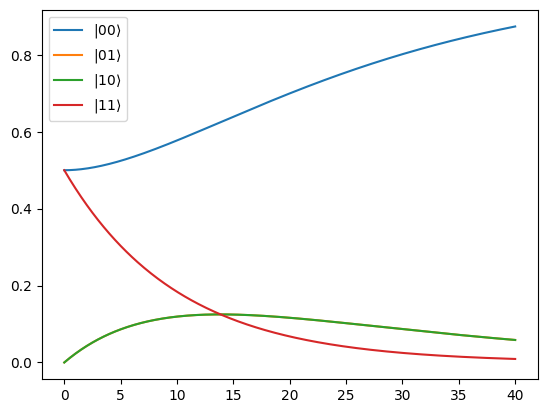

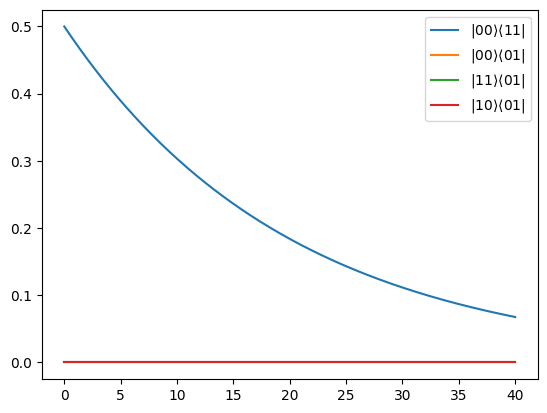

In [39]:
# 2 qubit - dissipation

J = 0 * 1e-3 * eV       # (meV)
dt = 0.1 * ps      # (ps)
n_steps = 400

H = np.array([
    [1,  0,  0, 0],
    [0, -1,  2, 0],
    [0,  2, -1, 0],
    [0,  0,  0, 1]
], dtype=complex)*J/4


I2 = np.eye(2, dtype=complex)
L1 = np.array([[0, 1],
               [0, 0]], dtype=complex) #relaks
L2 = np.array([[1,  0],
               [0, -1]], dtype=complex) #dephas

L = [np.kron(L1, I2), np.kron(I2, L1), np.kron(L2, I2), np.kron(I2, L2), np.kron(I2, L2)+np.kron(L2, I2)]

#linbladian parameters
tau0_relax1 = 20 * ps
tau0_relax2 = 20 * ps
tau0_deph1 = 40000000 * ps
tau0_deph2 = 40000000 * ps
tau0_cordeph = 100000000 * ps

gamma_relax1 = 1/tau0_relax1   # amplitude damping  (T1-type, relaxation to ground state)
gamma_relax2 = 1/tau0_relax2
gamma_deph1  = 1/tau0_deph1   # dephasing          (T2-type, pure dephasing)
gamma_deph2  = 1/tau0_deph2
gamma_cordeph  = 1/tau0_cordeph
gammas = [gamma_relax1, gamma_relax2, gamma_deph1, gamma_deph2, gamma_cordeph]


#starting vector
psi0np = np.array([1, 0, 0, 1], dtype=complex)
psi0 = psi0np / np.linalg.norm(psi0np)
psi0 = torch.tensor(psi0, dtype=torch.complex64)
rho0 = torch.outer(psi0, psi0.conj()).unsqueeze(0)


solver = Lindblad_solver(H, L_ops=L, gammas=gammas, dt=dt)
[times, rhos]  = solver.run_simulation(rho0, n_steps=n_steps)

# Plotting
rhos_np = np.array(rhos)  # shape: (n_steps+1, 4, 4) or (n_steps+1, 1, 4, 4)

# Squeeze batch dim if present
if rhos_np.ndim == 4:
    rhos_np = rhos_np.squeeze(1)

pop_00 = rhos_np[:, 0, 0].real
pop_01 = rhos_np[:, 1, 1].real
pop_10 = rhos_np[:, 2, 2].real
pop_11 = rhos_np[:, 3, 3].real

coh_00_11 = np.abs(rhos_np[:, 0, 3])
coh_00_01 = np.abs(rhos_np[:, 0, 1])
coh_11_01 = np.abs(rhos_np[:, 3, 1])
coh_10_01 = np.abs(rhos_np[:, 3, 1])

plot_signals([pop_00, pop_01, pop_10, pop_11],
             labels = [r'$|00\rangle$', r'$|01\rangle$', r'$|10\rangle$', r'$|11\rangle$'],
             t_axis = times/ps)

plot_signals([coh_00_11, coh_00_01, coh_11_01, coh_10_01],
             labels = [r'$|00\rangle\langle11|$', r'$|00\rangle\langle01|$', r'$|11\rangle\langle01|$', r'$|10\rangle\langle01|$'],
             t_axis = times/ps)

C:\Users\Ziemowit\AppData\Local\Temp\ipykernel_10344\2397025110.py:63: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  rho = torch.tensor(np.array(rho0, dtype=complex))


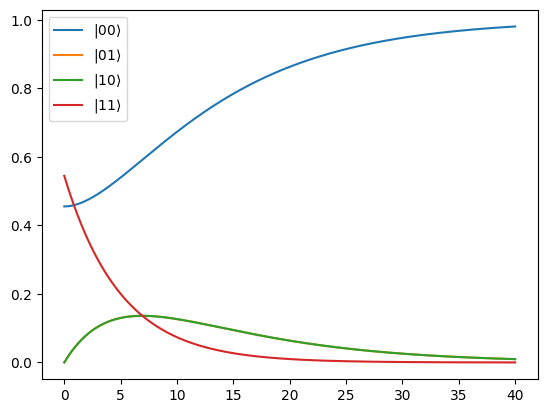

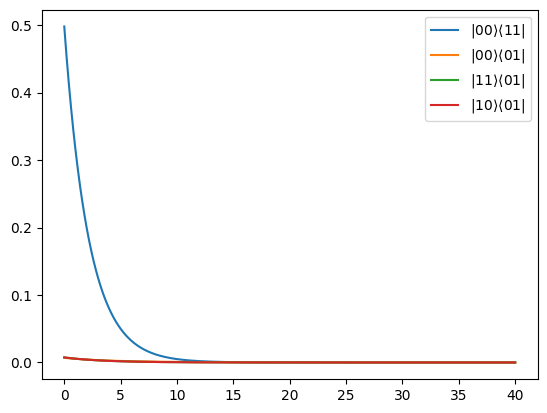

In [29]:
#evolution with modified starting vector

#linbladian parameters
gamma_relax1 = 1/tau0_relax1   # amplitude damping  (T1-type, relaxation to ground state)
gamma_relax2 = 1/tau0_relax2
gamma_deph1  = 1/tau0_deph1   # dephasing          (T2-type, pure dephasing)
gamma_deph2  = 1/tau0_deph2
gamma_cordeph  = 1/tau0_cordeph
gammas = [gamma_relax1, gamma_relax2, gamma_deph1, gamma_deph2, gamma_cordeph]


#starting vector
mod_amplitude = 0.1
psi0_mod = psi0np + np.array([rand_cplx(mod_amplitude), rand_cplx(mod_amplitude), rand_cplx(mod_amplitude), rand_cplx(mod_amplitude)])
psi0_mod /= np.linalg.norm(psi0_mod)
psi0_mod = torch.tensor(psi0_mod, dtype=torch.complex64)
rho0_mod = torch.outer(psi0_mod, psi0_mod.conj()).unsqueeze(0)

solver = Lindblad_solver(H, L_ops=L, gammas=gammas, dt=dt)
[times, rhos]  = solver.run_simulation(rho0_mod, n_steps=n_steps)

# Plotting
rhos_np = np.array(rhos)  # shape: (n_steps+1, 4, 4) or (n_steps+1, 1, 4, 4)

# Squeeze batch dim if present
if rhos_np.ndim == 4:
    rhos_np = rhos_np.squeeze(1)

pop_00 = rhos_np[:, 0, 0].real
pop_01 = rhos_np[:, 1, 1].real
pop_10 = rhos_np[:, 2, 2].real
pop_11 = rhos_np[:, 3, 3].real

coh_00_11 = np.abs(rhos_np[:, 0, 3])
coh_00_01 = np.abs(rhos_np[:, 0, 1])
coh_11_01 = np.abs(rhos_np[:, 3, 1])
coh_10_01 = np.abs(rhos_np[:, 3, 1])

plot_signals([pop_00, pop_01, pop_10, pop_11],
             labels = [r'$|00\rangle$', r'$|01\rangle$', r'$|10\rangle$', r'$|11\rangle$'],
             t_axis = times/ps)

plot_signals([coh_00_11, coh_00_01, coh_11_01, coh_10_01],
             labels = [r'$|00\rangle\langle11|$', r'$|00\rangle\langle01|$', r'$|11\rangle\langle01|$', r'$|10\rangle\langle01|$'],
             t_axis = times/ps)

C:\Users\Ziemowit\AppData\Local\Temp\ipykernel_10344\2397025110.py:63: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  rho = torch.tensor(np.array(rho0, dtype=complex))


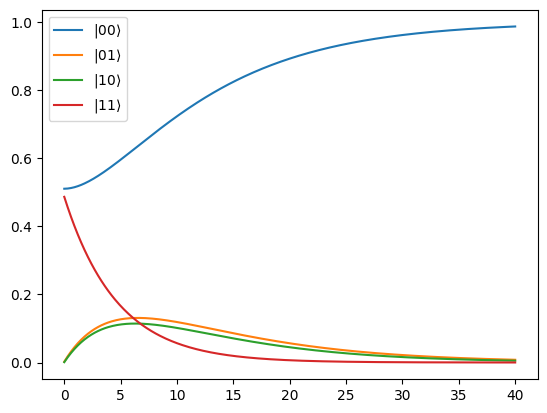

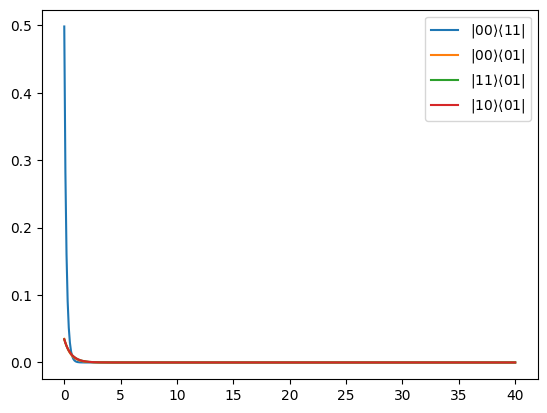

In [33]:
#evolution with modified starting vector and lindbladian parameters

#linbladian parameters
tau_relax1 = tau0_relax1 * np.random.uniform(0.8, 1.2)
tau_relax2 = tau0_relax1 * np.random.uniform(0.1, 2)
tau_deph1 = tau0_relax1 * np.random.uniform(0.1, 2)
tau_deph2 = tau0_relax1 * np.random.uniform(0.1, 2)
tau_cordeph = tau0_relax1 * np.random.uniform(0.1, 2)

gamma_relax1 = 1/tau_relax1   # amplitude damping  (T1-type, relaxation to ground state)
gamma_relax2 = 1/tau_relax2
gamma_deph1  = 1/tau_deph1   # dephasing          (T2-type, pure dephasing)
gamma_deph2  = 1/tau_deph2
gamma_cordeph  = 1/tau_cordeph
gammas = [gamma_relax1, gamma_relax2, gamma_deph1, gamma_deph2, gamma_cordeph]


#starting vector
mod_amplitude = 0.1
psi0_mod = psi0np + np.array([rand_cplx(mod_amplitude), rand_cplx(mod_amplitude), rand_cplx(mod_amplitude), rand_cplx(mod_amplitude)])
psi0_mod /= np.linalg.norm(psi0_mod)
psi0_mod = torch.tensor(psi0_mod, dtype=torch.complex64)
rho0_mod = torch.outer(psi0_mod, psi0_mod.conj()).unsqueeze(0)

solver = Lindblad_solver(H, L_ops=L, gammas=gammas, dt=dt)
[times, rhos]  = solver.run_simulation(rho0_mod, n_steps=n_steps)

# Plotting
rhos_np = np.array(rhos)  # shape: (n_steps+1, 4, 4) or (n_steps+1, 1, 4, 4)

# Squeeze batch dim if present
if rhos_np.ndim == 4:
    rhos_np = rhos_np.squeeze(1)

pop_00 = rhos_np[:, 0, 0].real
pop_01 = rhos_np[:, 1, 1].real
pop_10 = rhos_np[:, 2, 2].real
pop_11 = rhos_np[:, 3, 3].real

coh_00_11 = np.abs(rhos_np[:, 0, 3])
coh_00_01 = np.abs(rhos_np[:, 0, 1])
coh_11_01 = np.abs(rhos_np[:, 3, 1])
coh_10_01 = np.abs(rhos_np[:, 3, 1])

plot_signals([pop_00, pop_01, pop_10, pop_11],
             labels = [r'$|00\rangle$', r'$|01\rangle$', r'$|10\rangle$', r'$|11\rangle$'],
             t_axis = times/ps)

plot_signals([coh_00_11, coh_00_01, coh_11_01, coh_10_01],
             labels = [r'$|00\rangle\langle11|$', r'$|00\rangle\langle01|$', r'$|11\rangle\langle01|$', r'$|10\rangle\langle01|$'],
             t_axis = times/ps)